# 🏥 Eksperimen 01: Composite Health Index & Penentuan Wilayah Prioritas Jawa Timur
**Mata Kuliah**: Proyek Analitika Data — Sains Data Terapan (PENS 2026)  
**Platform**: Cura (HealthTrust Platform)  
**Role**: Machine Learning Engineer  

---

### 📌 Tujuan Eksperimen:
1. **Integrasi Data Multi-Sektor**: Menggabungkan kapasitas faskes, profil nakes, morbiditas penyakit, dan indikator KIA (stunting, AKI, AKB) untuk 38 Kabupaten/Kota di Jawa Timur.
2. **Perumusan 5 Pilar Indeks Kesehatan Wilayah**:
   - Pilar 1: Kapasitas Fasilitas & Rasio Tempat Tidur Standar WHO (Bobot 25%)
   - Pilar 2: Ketersediaan & Rasio Tenaga Medis (Bobot 20%)
   - Pilar 3: Kesehatan Ibu, Anak & Prevalensi Stunting (Bobot 25%)
   - Pilar 4: Beban Morbiditas Kasus Rawat Inap & Menular (Bobot 15%)
   - Pilar 5: Cakupan Program Preventif & Imunisasi (Bobot 15%)
3. **Perhitungan Skor Kesehatan Jawa Timur (Provinsi & 38 Kab/Kota)** (0 - 100).
4. **Penetapan 8 Wilayah Prioritas Intervensi**: Mengidentifikasi kabupaten paling rentan yang membutuhkan penanganan darurat (sesuai KPI Dasbor Cura).
5. **Rekomendasi Program Berbasis Bukti**: Menghubungkan kelemahan spesifik tiap daerah dengan program kerja kesehatan Jawa Timur.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print("Library analitika berhasil dimuat!")

Library analitika berhasil dimuat!


## 1. Data Ingestion & Integrasi
Kita memuat `ml_readiness_dataset.csv` (feature store 38 Kab/Kota) dan menggabungkannya dengan `maternal_child_health.csv`.

In [2]:
# Load dataset
df_ml = pd.read_csv('../../database/exports/ml_readiness_dataset.csv')
df_kia = pd.read_csv('../../database/exports/maternal_child_health.csv')

# Merge on kode_bps
cols_kia = ['kode_bps', 'aki', 'akb', 'prevalensi_stunting', 'cakupan_idl', 'k4_coverage', 'persen_persalinan_faskes']
df_merged = pd.merge(df_ml, df_kia[cols_kia], on='kode_bps')

print(f"Dimensi dataset gabungan: {df_merged.shape}")
df_merged[['kode_bps', 'nama_wilayah', 'rasio_tt_proyeksi_2026', 'rasio_dokter_per_1000', 'prevalensi_stunting', 'aki']].head(5)

Dimensi dataset gabungan: (38, 36)


,kode_bps,nama_wilayah,rasio_tt_proyeksi_2026,rasio_dokter_per_1000,prevalensi_stunting,aki
0,3501,Kabupaten Pacitan,0.59,0.172,13.34,107.1
1,3502,Kabupaten Ponorogo,1.26,0.150,19.80,97.2
2,3503,Kabupaten Trenggalek,0.93,0.130,16.31,87.2
3,3504,Kabupaten Tulungagung,1.91,0.143,12.55,81.4
4,3505,Kabupaten Blitar,0.75,0.212,12.86,101.7


## 2. Perumusan 5 Pilar & Normalisasi Indikator
Setiap indikator dinormalisasi ke skala 0–100:
- **Indikator Positif** (kapasitas ranjang, rasio dokter, cakupan imunisasi): Nilai tinggi = Skor tinggi.
- **Indikator Beban/Negatif** (stunting, AKI, AKB, beban kasus penyakit): Nilai rendah = Skor tinggi.

In [3]:
def minmax_pos(series):
    s_min, s_max = series.min(), series.max()
    return ((series - s_min) / (s_max - s_min)) * 100.0 if s_max > s_min else series * 0 + 50.0

def minmax_neg(series):
    s_min, s_max = series.min(), series.max()
    return ((s_max - series) / (s_max - s_min)) * 100.0 if s_max > s_min else series * 0 + 50.0

res = df_merged.copy()
pop_2026 = res['proyeksi_penduduk_2026']

# 1. Pilar Fasilitas (25%)
bed_capped = res['rasio_tt_proyeksi_2026'].clip(upper=3.0)
score_bed = minmax_pos(bed_capped)
score_pkm = minmax_pos((res['total_puskesmas'] / pop_2026) * 100000)
score_pkm_tt = minmax_pos((res['total_tt_puskesmas'] / pop_2026) * 100000)
res['pilar_fasilitas'] = (0.50 * score_bed + 0.30 * score_pkm + 0.20 * score_pkm_tt).round(2)

# 2. Pilar Nakes (20%)
res['pilar_nakes'] = (0.45 * minmax_pos(res['rasio_dokter_per_1000']) + 
                      0.30 * minmax_pos(res['rasio_perawat_per_1000']) + 
                      0.25 * minmax_pos(res['rasio_bidan_per_1000'])).round(2)

# 3. Pilar KIA & Stunting (25%)
res['pilar_kia'] = (0.50 * minmax_neg(res['prevalensi_stunting']) + 
                    0.25 * minmax_neg(res['aki']) + 
                    0.25 * minmax_neg(res['akb'])).round(2)

# 4. Pilar Morbiditas (15%)
res['pilar_morbiditas'] = (0.50 * minmax_neg((res['kasus_rawat_inap_tahunan'] / pop_2026) * 1000) + 
                          0.50 * minmax_neg((res['kasus_menular_tahunan'] / pop_2026) * 1000)).round(2)

# 5. Pilar Cakupan Program (15%)
res['pilar_program'] = (0.40 * minmax_pos(res['cakupan_idl']) + 
                        0.30 * minmax_pos(res['k4_coverage']) + 
                        0.30 * minmax_pos(res['persen_persalinan_faskes'])).round(2)

# Composite Health Score
res['skor_kesehatan'] = (
    0.25 * res['pilar_fasilitas'] +
    0.20 * res['pilar_nakes'] +
    0.25 * res['pilar_kia'] +
    0.15 * res['pilar_morbiditas'] +
    0.15 * res['pilar_program']
).round(2)

# Kategori Status
def classify_status(s):
    if s >= 55.0: return 'Tangguh / Mandiri'
    elif s >= 40.0: return 'Waspada'
    else: return 'Prioritas Intervensi'

res['kategori_status'] = res['skor_kesehatan'].apply(classify_status)
res['rank_provinsi'] = res['skor_kesehatan'].rank(ascending=False, method='min').astype(int)

mean_jatim = res['skor_kesehatan'].mean()
print(f"Rata-rata Skor Jawa Timur: {mean_jatim:.2f} / 100")

Rata-rata Skor Jawa Timur: 47.09 / 100


## 3. Visualisasi Peringkat Skor Kesehatan 38 Kab/Kota
Grafik batang di bawah menunjukkan urutan ketahanan kesehatan dari wilayah tertinggi hingga terendah.

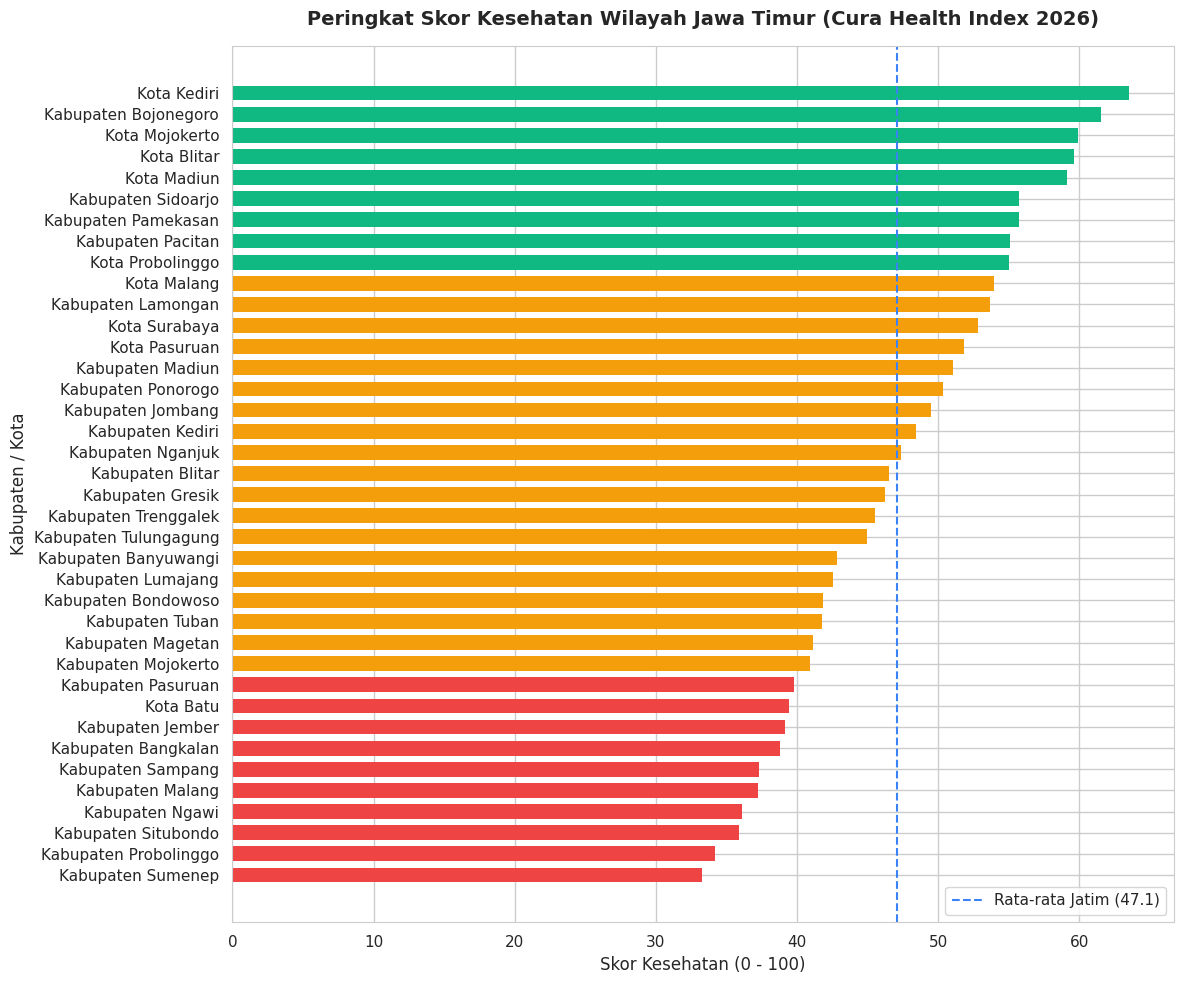

In [4]:
plt.figure(figsize=(12, 10))
df_sorted = res.sort_values('skor_kesehatan', ascending=True)

colors = df_sorted['kategori_status'].map({
    'Tangguh / Mandiri': '#10B981',
    'Waspada': '#F59E0B',
    'Prioritas Intervensi': '#EF4444'
})

bars = plt.barh(df_sorted['nama_wilayah'], df_sorted['skor_kesehatan'], color=colors, edgecolor='none', height=0.7)
plt.axvline(mean_jatim, color='#3B82F6', linestyle='--', linewidth=1.5, label=f'Rata-rata Jatim ({mean_jatim:.1f})')

plt.title('Peringkat Skor Kesehatan Wilayah Jawa Timur (Cura Health Index 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skor Kesehatan (0 - 100)', fontsize=12)
plt.ylabel('Kabupaten / Kota', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 4. Analisis 8 Wilayah Prioritas Intervensi
Sesuai KPI Dasbor Cura (Overview & Program Recommendation), 8 kabupaten di bawah memiliki skor terendah dan membutuhkan intervensi terfokus.

In [5]:
prioritas_df = res[res['kategori_status'] == 'Prioritas Intervensi'].sort_values('skor_kesehatan')
display_cols = ['rank_provinsi', 'nama_wilayah', 'skor_kesehatan', 'pilar_fasilitas', 'pilar_nakes', 'pilar_kia', 'pilar_morbiditas', 'pilar_program']
print(f"Total Wilayah Prioritas: {len(prioritas_df)} Kabupaten/Kota")
prioritas_df[display_cols]

Total Wilayah Prioritas: 10 Kabupaten/Kota


,rank_provinsi,nama_wilayah,skor_kesehatan,pilar_fasilitas,pilar_nakes,pilar_kia,pilar_morbiditas,pilar_program
28,38,Kabupaten Sumenep,33.29,30.97,48.48,29.23,25.53,31.42
12,37,Kabupaten Probolinggo,34.16,27.57,35.39,29.27,50.64,35.16
11,36,Kabupaten Situbondo,35.89,40.57,14.00,46.93,30.01,44.73
20,35,Kabupaten Ngawi,36.11,40.01,33.39,36.05,47.67,21.76
6,34,Kabupaten Malang,37.23,17.94,11.90,33.31,82.26,64.64
26,33,Kabupaten Sampang,37.31,18.02,30.93,23.11,94.32,44.64
25,32,Kabupaten Bangkalan,38.80,32.04,53.24,31.55,42.64,39.07
8,31,Kabupaten Jember,39.11,18.54,36.40,52.44,32.58,61.30
37,30,Kota Batu,39.42,67.58,3.01,46.51,47.01,21.63
13,29,Kabupaten Pasuruan,39.76,24.31,36.47,43.58,57.98,45.28
